# Exploratory Data Analysis

It is the main nootebook related to Exploratory Data Analysis (EDA) of https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv dataset

## Notebook initialization

In [1]:
# Notebook initialization
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd()

while not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# print("Project root:", ROOT)

## Imports & Load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_raw_data

raw_df = load_raw_data()
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Missing values

In [3]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:
raw_df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

 - no missing values in dataset

## Target Column

In [5]:
target_col = "y"
raw_df[target_col].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

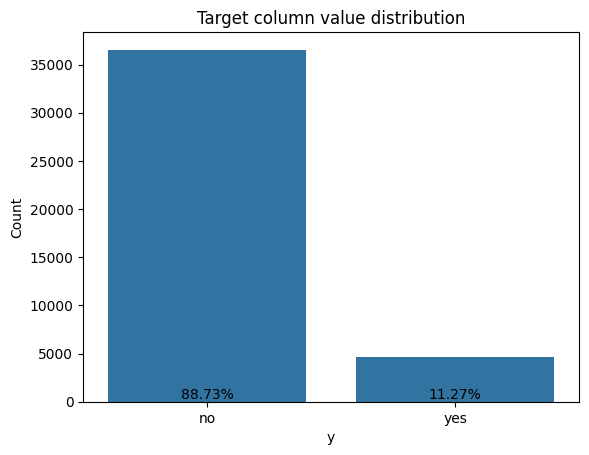

In [6]:
from src.visualizations import plot_column_distribution

plot_column_distribution(raw_df, target_col, title="Target column value distribution")

 - there is target values class imbalance in training data

## Split numeric and categorical columns

In [7]:
from src.data import split_numeric_categorical

splits = split_numeric_categorical(raw_df)

X_num = splits["X_numeric"]
y_num = splits["y_numeric"]
numeric_df = pd.concat([X_num, y_num], axis=1)

X_cat = splits["X_categorical"]
y_cat = splits["y_categorical"]
categorical_df = pd.concat([X_num, y_num], axis=1)

X_num.shape, X_cat.shape

((41188, 10), (41188, 10))

 - there are 10 numeric and 10 categorical features in dataset

## Correlations numeric

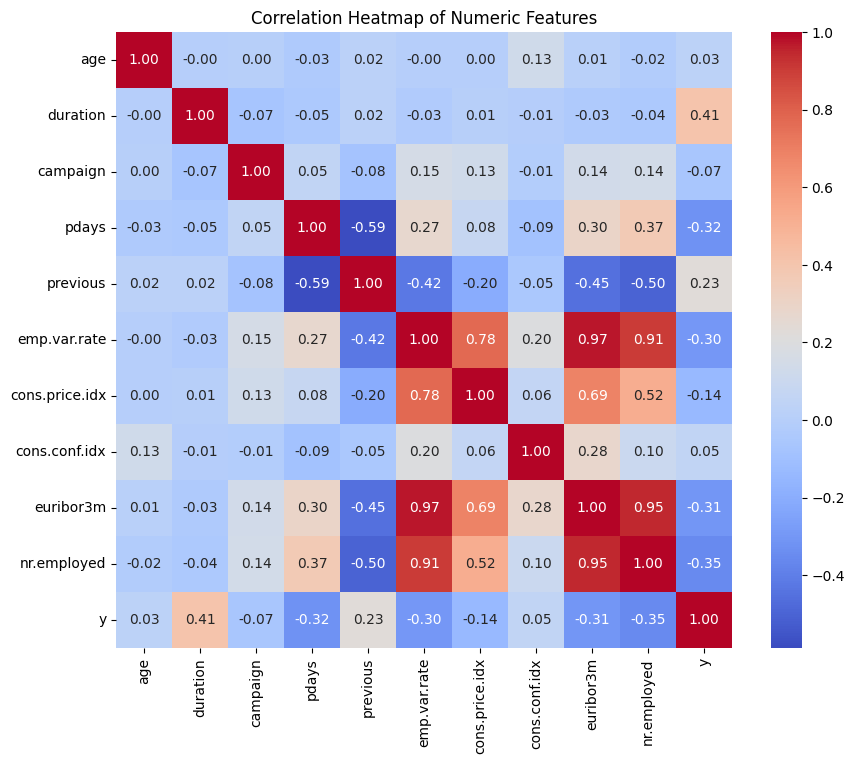

In [8]:
corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## Numeric columns

### All box-plots (raw data)

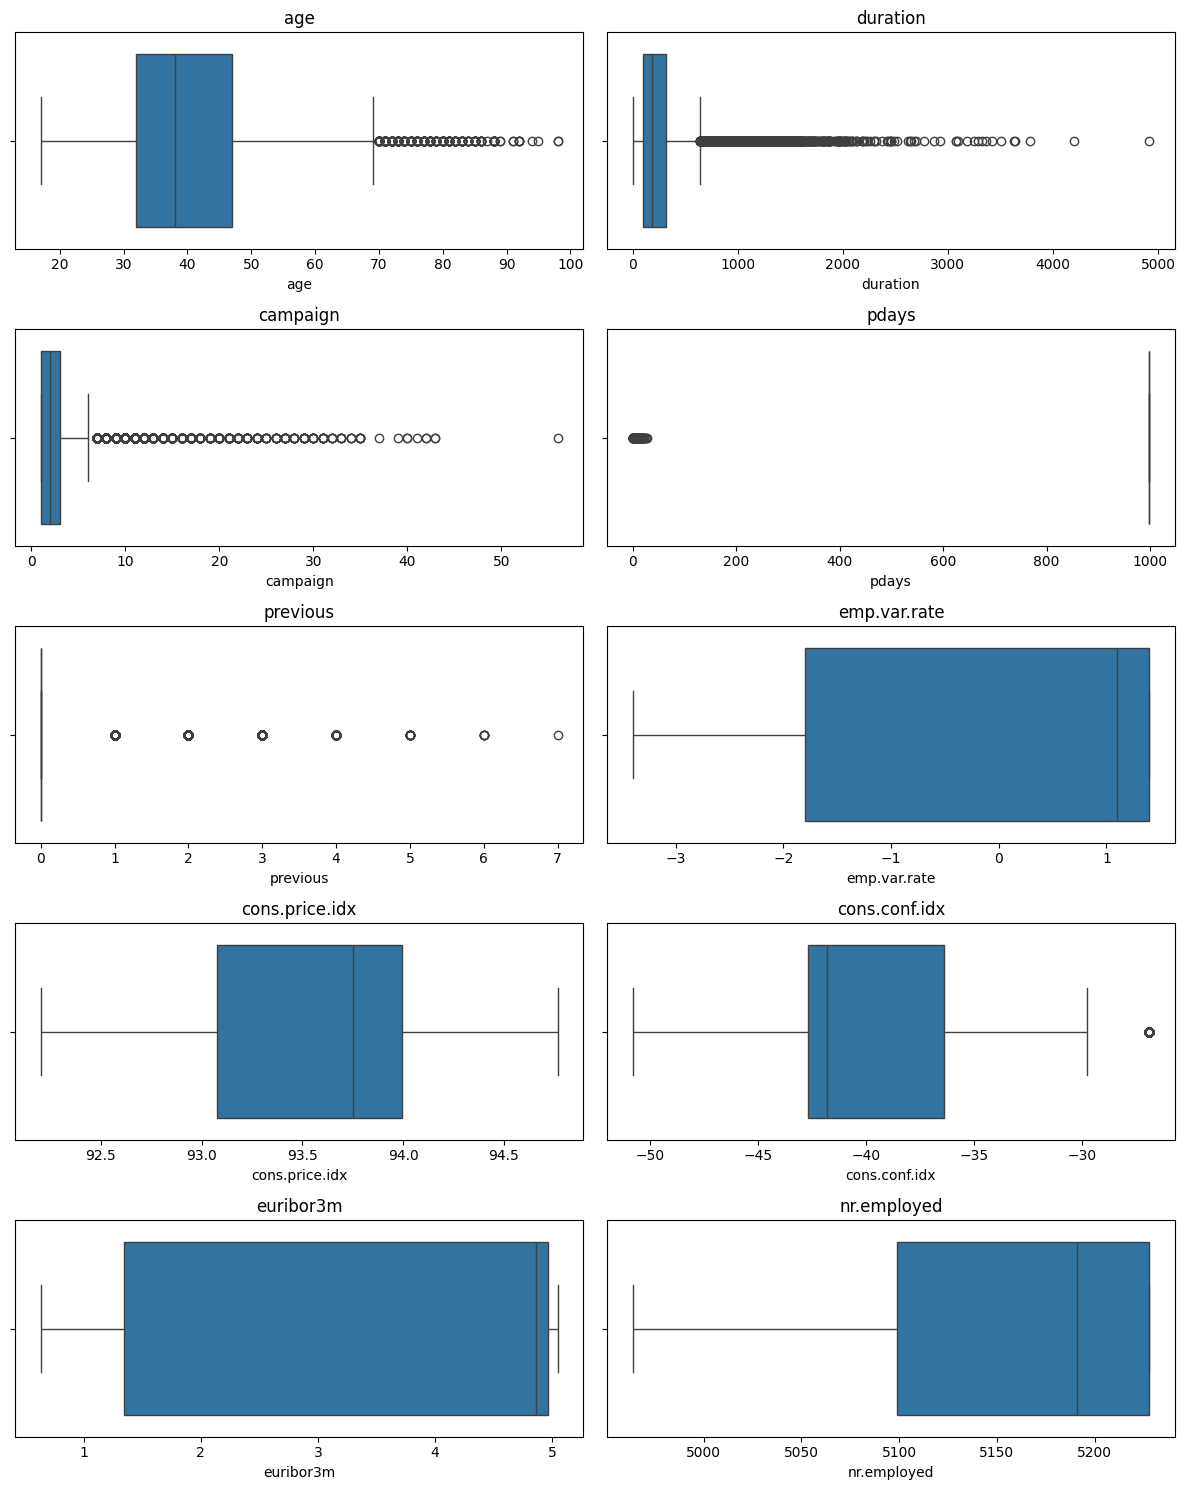

In [9]:
from src.visualizations import plot_numeric_boxplots_grid

plot_numeric_boxplots_grid(numeric_df, target_col)

 - duration, campaigns, pdays, previous cols definitely require additional analysis

### Duration column

In [10]:
numeric_df["duration"].describe()

count    41188.000000
mean       258.285010
std        259.279249
min          0.000000
25%        102.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

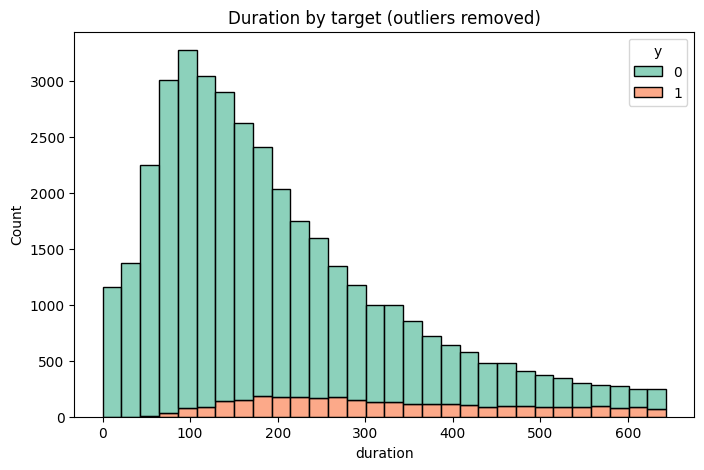

In [11]:
from src.visualizations import plot_histogram
from src.outliers import remove_outliers_iqr, replace_outliers_iqr

plot_histogram(
    remove_outliers_iqr(numeric_df, "duration"),
    "duration",
    target_col="y",
    show_pct=False,
    title="Duration by target (outliers removed)",
)

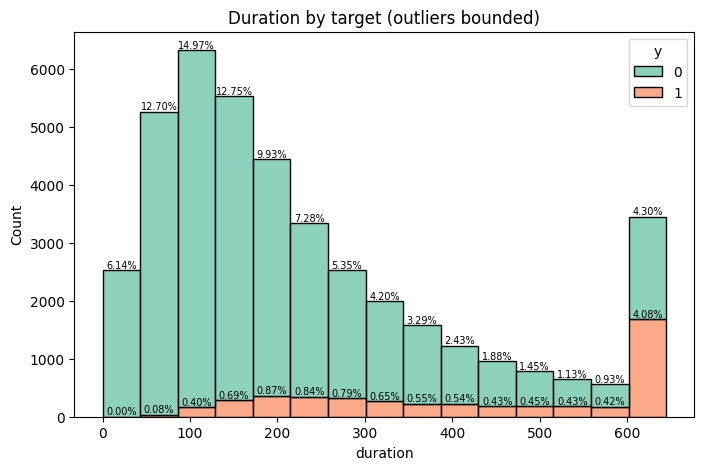

In [12]:
plot_histogram(
    replace_outliers_iqr(numeric_df, "duration", replace_with=None), 
    "duration",
    target_col="y",
    show_pct=True,
    bins=15,
    title="Duration by target (outliers bounded)",
)

 - duration 0 always 'no'
 - longer duration - more probability of 'yes'

### Campaign column

In [13]:
numeric_df["campaign"].describe()

count    41188.000000
mean         2.567593
std          2.770014
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

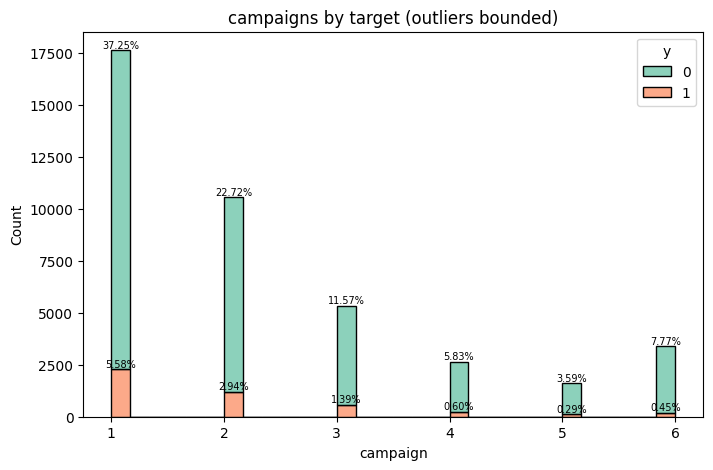

In [14]:
plot_histogram(
    replace_outliers_iqr(numeric_df, "campaign", replace_with=None),
    "campaign",
    target_col="y",
    show_pct=True,
    title="campaigns by target (outliers bounded)",
)

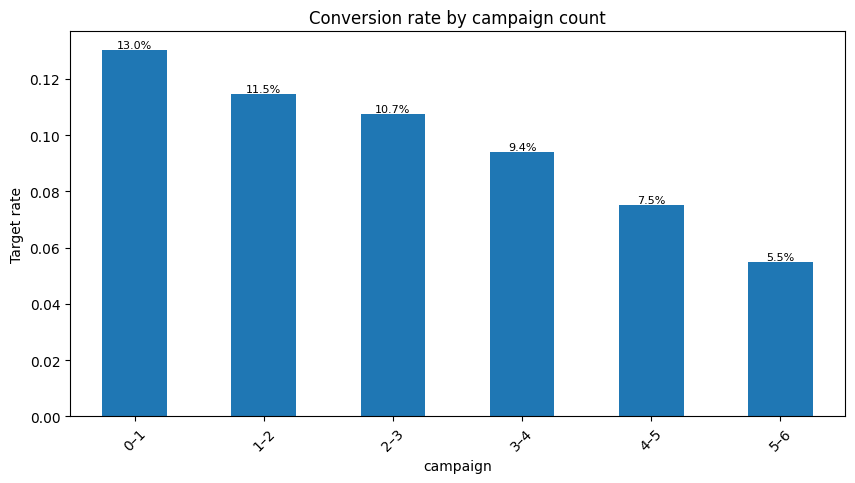

In [15]:
from src.visualizations import plot_target_rate_by_bin

plot_target_rate_by_bin(
    replace_outliers_iqr(numeric_df, "campaign", replace_with=None),
    col="campaign",
    target_col="y",
    title="Conversion rate by campaign count",
)

 - there is less probability of 'yes' target with each next campaign

### pdays column

In [16]:
numeric_df["pdays"].describe()

count    41188.000000
mean       962.475454
std        186.910907
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64

In [17]:
numeric_df[numeric_df["pdays"] != 999].shape, numeric_df[numeric_df["pdays"] == 999].shape

((1515, 11), (39673, 11))

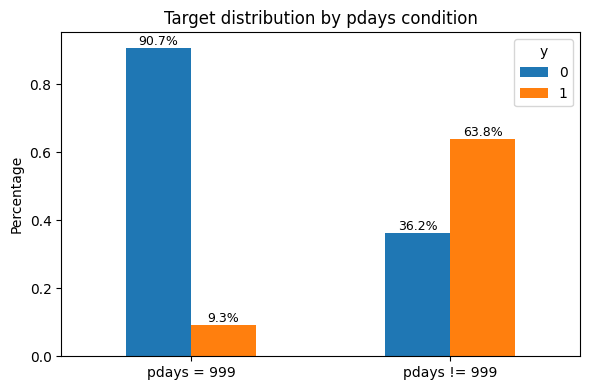

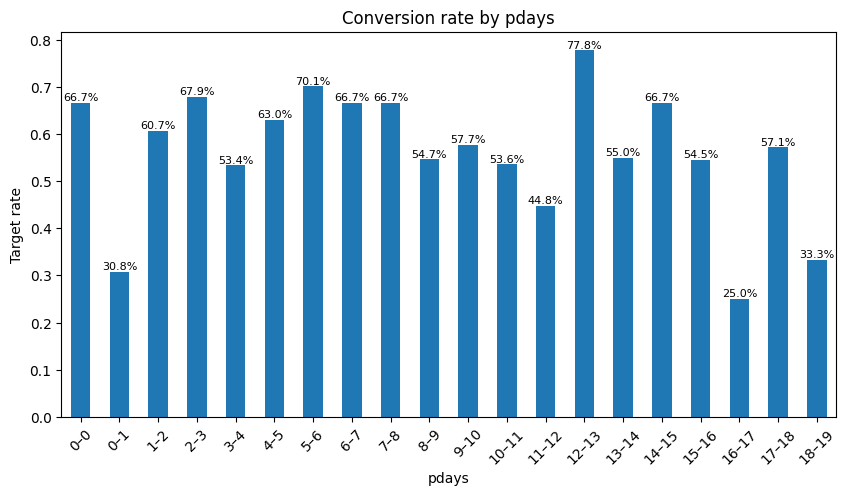

In [18]:
from src.visualizations import plot_target_distribution_by_value

plot_target_distribution_by_value(numeric_df, "pdays", 999, target_col)

plot_target_rate_by_bin(
    numeric_df[numeric_df["pdays"] < 20],
    col="pdays",
    target_col="y",
    title="Conversion rate by pdays",
)

 - contacting customer (pdays != 999) definetely increase possibility of 'yes' target
 - number of days since last contact does not seem to have any impact on target

### previous column

In [19]:
numeric_df[numeric_df["previous"] != 0].shape, numeric_df[numeric_df["previous"] == 0].shape

((5625, 11), (35563, 11))

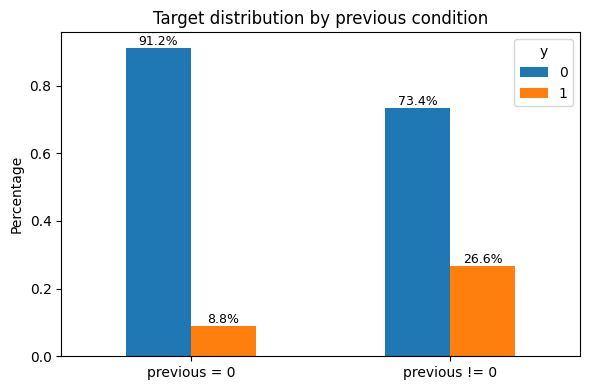

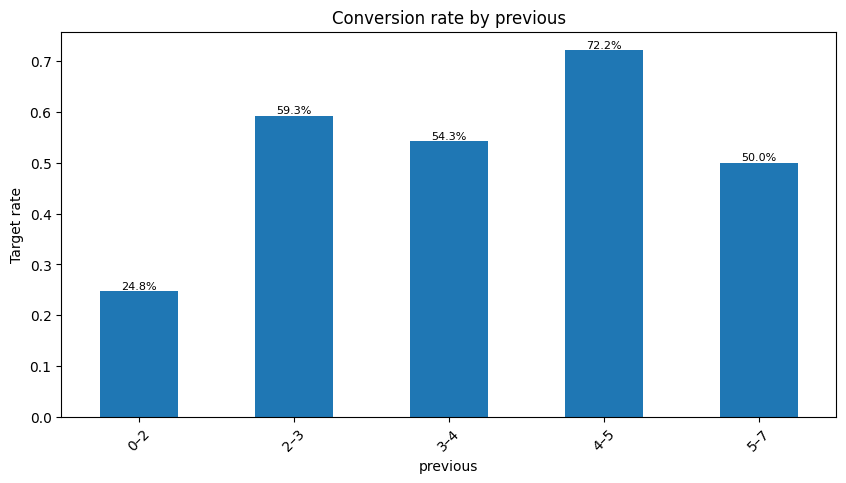

In [20]:
plot_target_distribution_by_value(numeric_df, "previous", 0, target_col)

plot_target_rate_by_bin(
    numeric_df[numeric_df["previous"] > 0],
    col="previous",
    target_col="y",
    title="Conversion rate by previous",
    bins=5
)

 - previous > 0 seems to have positive impact on probability of target 'yes' value

### Socio-economic context columns (emp.var.rate, cons.price.idx, etc)

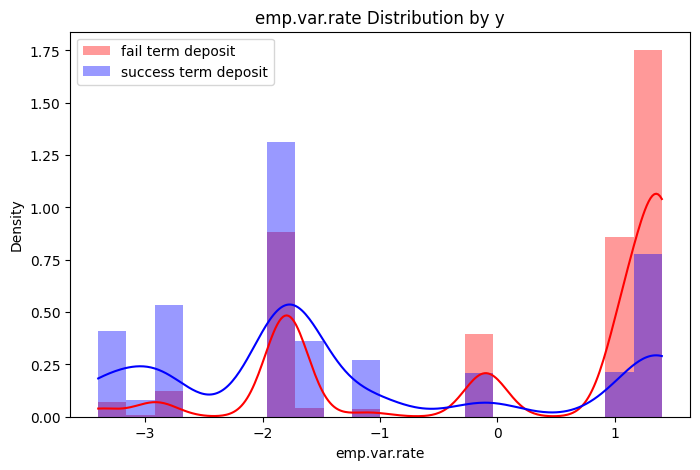

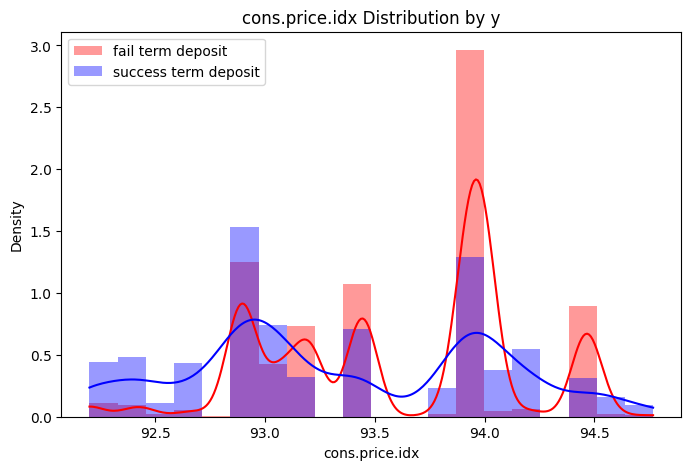

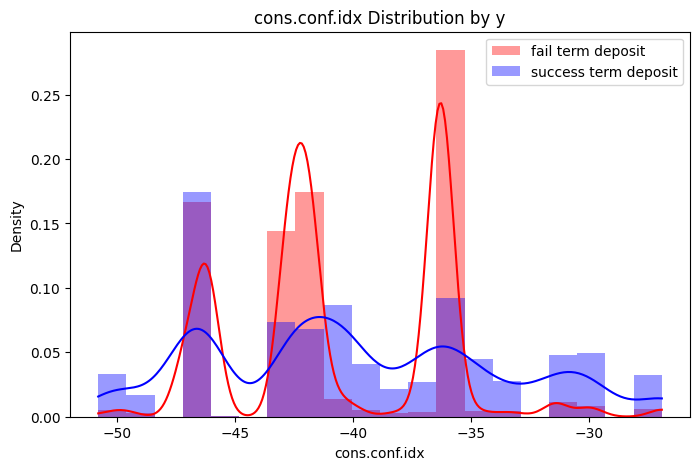

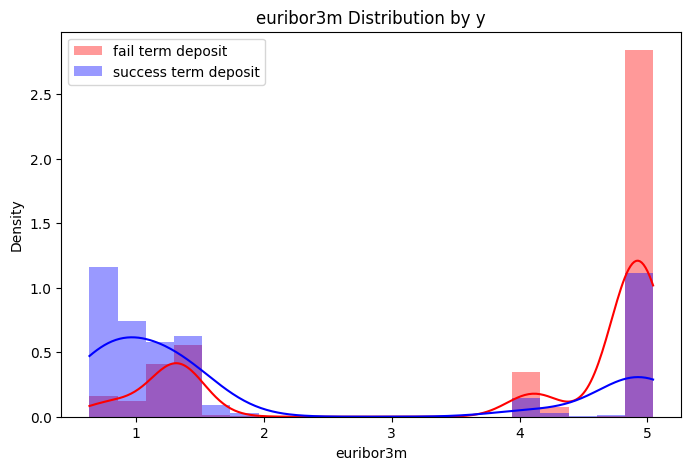

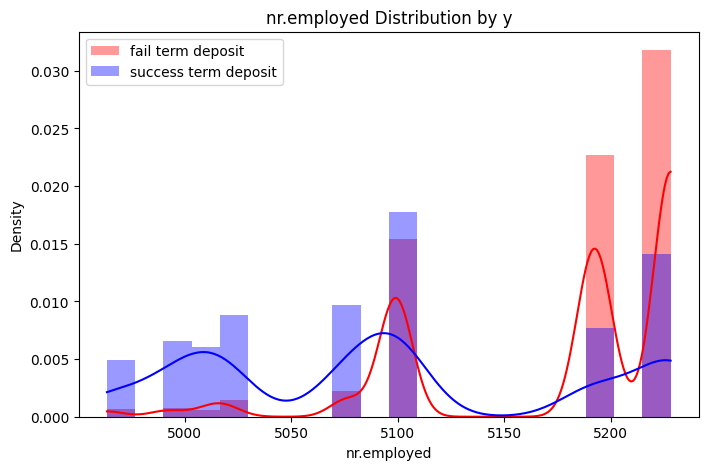

In [28]:
from src.visualizations import plt_histogram_kde

cols = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

for col in cols:
    plt_histogram_kde(
        numeric_df,
        col=col,
        color_col=target_col,
        labels={0: "fail term deposit", 1: "success term deposit"},
        density=True,
        bins=20,
    )

 - greater emp.var.rate more probability of 'no' target
 - greater euribor3m more probability of 'no' target
 - greater nr.employed more probability of 'no' target
 - cons.price.idx and cons.conf.idx are not evenly distributed for 'yes' and 'no' target. some values seems to impact target to one or another side